# Tarea 2 DAAML

Daniel Alejandro Gonzalez Miranda | 2022436727

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import statsmodels.api as sm
import statsmodels.formula.api as smf
from statsmodels.iolib.summary2 import summary_col
from linearmodels.panel import PooledOLS, PanelOLS, RandomEffects
from linearmodels.panel import compare
from pysyncon import Dataprep, Synth, AugSynth, PenalizedSynth
import seaborn as sns
import scipy.stats as stats
import warnings
warnings.filterwarnings("ignore")

%matplotlib inline
sns.set_style("whitegrid")

### 1. Cargar la base de datos en el ambiente. Identifique los tipos de datos que se encuentran en la base, realice estadisticas descriptivas sobre las variables importantes (Hint: Revisar la distribuciones, datos faltantes, outliers, etc.) y limpie las variables cuando sea necesario.

In [2]:
# importamos los datos
df = pd.read_csv("dataset_prueba.csv")
df['date'] = pd.to_datetime(df['date'])
data = df.copy()

print(f"Dimensiones de la base: {data.shape[0]} observaciones y {data.shape[1]} variables.")

Dimensiones de la base: 12040 observaciones y 41 variables.


In [3]:
# Identificamos los tipos de datos en la base
data.dtypes.value_counts()

float64           28
int64              8
object             4
datetime64[ns]     1
Name: count, dtype: int64

In [4]:
# Estadísticas descriptivas de variables clave
variables_clave = ['workplaces', 'Valor_Stringency_Index', 'daily_cases', 'unemp', 'age_dependency', 'foreigners']
data[variables_clave].describe().T[['count', 'mean', 'std', 'min', 'max']]

,count,mean,std,min,max
workplaces,12040.0,-18.667353,11.801356,-76.787132,19.057630
Valor_Stringency_Index,12040.0,27.486254,29.835937,0.000000,93.520000
daily_cases,12040.0,2355.733422,3154.914356,0.000000,22203.314200
unemp,12040.0,12.220515,8.265315,3.000000,36.000000
age_dependency,12040.0,0.653934,0.072849,0.520499,0.837478
foreigners,12040.0,8.145515,2.991933,2.000000,15.000000


In [5]:
# Revisamos datos faltantes en la base
missing = data.isnull().sum()
print("Variables con datos vacíos:")
print(missing[missing > 0])

Variables con datos vacíos:
edu2    5460
edu3    5460
dtype: int64


Las únicas variables con datos faltantes son `edu2` y `edu3`, con 5.460 valores nulos cada una (aproximadamente el 45% del total del panel). Para no perder observaciones en caso de utilizarlas, completamos estos datos vacíos imputando la media por ciudad (`CODE`). Sin embargo, no incluiremos estas variables de educación en las regresiones principales para evitar ruidos. El resto de las variables del panel están completamente limpias.

In [6]:
# Imputamos los valores faltantes de las variables educativas con la media de su ciudad
data['edu2'] = data.groupby('CODE')['edu2'].transform(lambda x: x.fillna(x.mean()))
data['edu3'] = data.groupby('CODE')['edu3'].transform(lambda x: x.fillna(x.mean()))

# Definimos la estructura del panel
print(f"Número de ciudades únicas: {data['NAME'].nunique()}")
print(f"Países en la base: {list(data['country'].unique())}")
print(f"Período temporal: {data['date'].min().date()} a {data['date'].max().date()}")

obs_por_ciudad = data.groupby('NAME')['date'].count()
print(f"-> Panel perfectamente BALANCEADO: {obs_por_ciudad.nunique() == 1} (todas las ciudades tienen {obs_por_ciudad.iloc[0]} observaciones)")

Número de ciudades únicas: 86
Países en la base: ['DE', 'ES', 'FR', 'IT', 'SE']
Período temporal: 2020-02-17 a 2022-10-17
-> Panel perfectamente BALANCEADO: True (todas las ciudades tienen 140 observaciones)


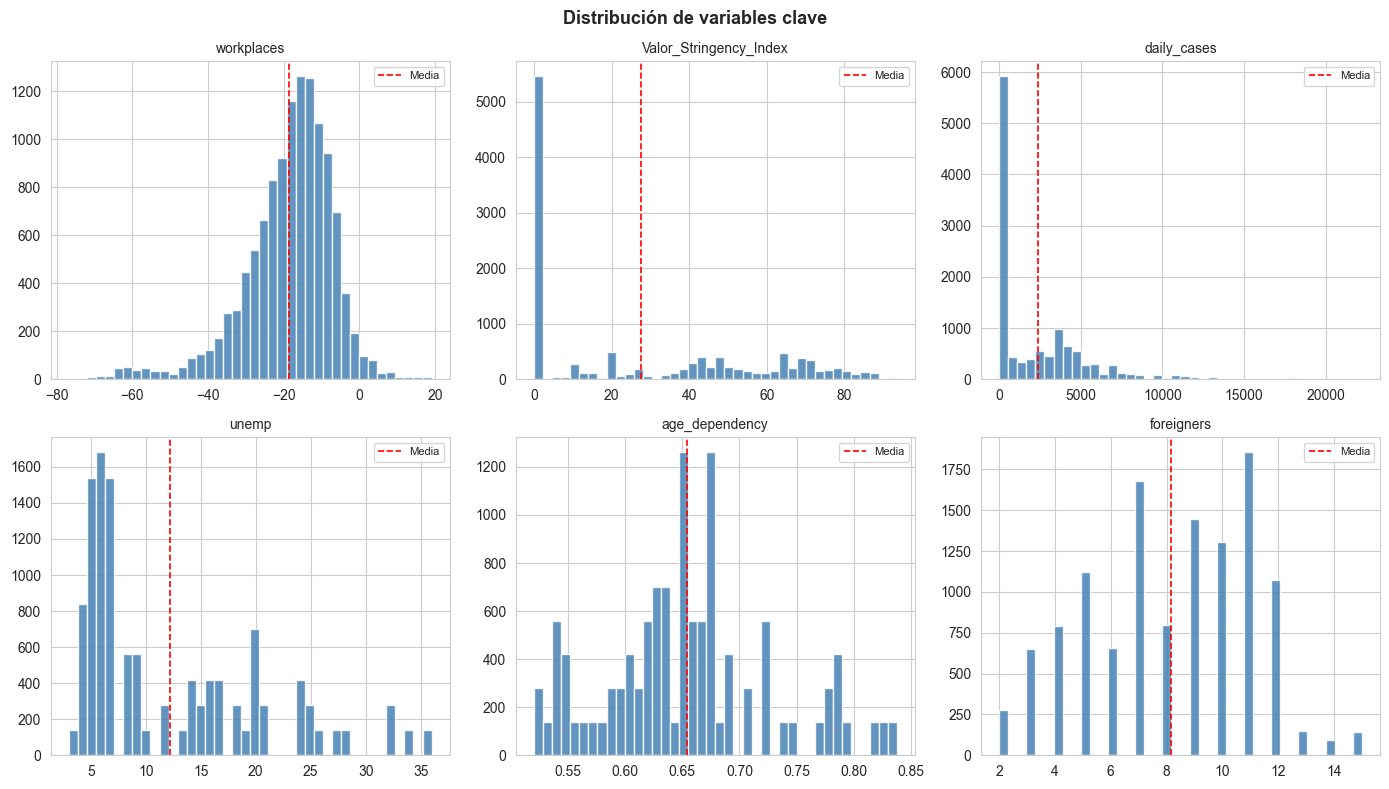

In [7]:
# Visualizamos las distribuciones de las variables principales
fig, axes = plt.subplots(2, 3, figsize=(14, 8))
axes = axes.flatten()

variables_plot = ['workplaces', 'Valor_Stringency_Index', 'daily_cases', 
                  'unemp', 'age_dependency', 'foreigners']

for i, var in enumerate(variables_plot):
    axes[i].hist(data[var], bins=40, edgecolor='white', color='steelblue', alpha=0.85)
    axes[i].set_title(var, fontsize=10)
    axes[i].axvline(data[var].mean(), color='red', linestyle='--', linewidth=1.2, label='Media')
    axes[i].legend(fontsize=8)

plt.suptitle("Distribución de variables clave", fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

In [8]:
# Como la variable de casos diarios 'daily_cases' tiene una fuerte asimetría a la derecha,
# aplicamos la transformación logarítmica log(1 + x) para estabilizar su varianza en los modelos
data['log_cases'] = np.log1p(data['daily_cases'])

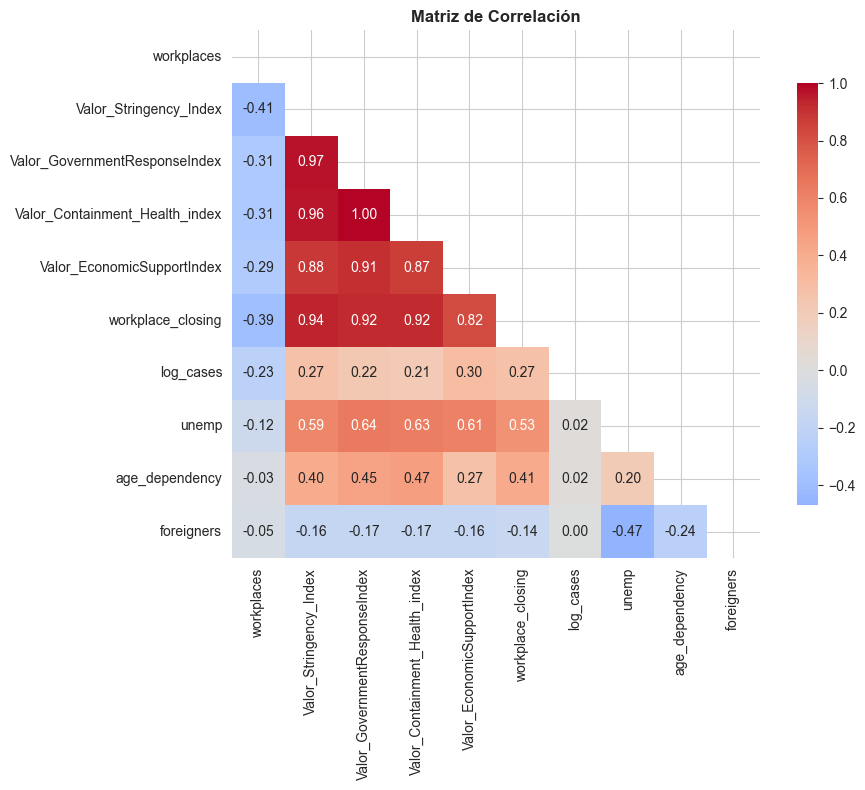

Correlaciones directas con workplaces:
Valor_Stringency_Index           -0.41
workplace_closing                -0.39
Valor_Containment_Health_index   -0.31
Valor_GovernmentResponseIndex    -0.31
Valor_EconomicSupportIndex       -0.29
log_cases                        -0.23
unemp                            -0.12
foreigners                       -0.05
age_dependency                   -0.03
workplaces                        1.00
Name: workplaces, dtype: float64


In [9]:
# Matriz de correlaciones para evaluar relaciones preliminares y colinealidad
fig, ax = plt.subplots(figsize=(10, 8))
variables_corr = ['workplaces', 'Valor_Stringency_Index', 'Valor_GovernmentResponseIndex', 
                  'Valor_Containment_Health_index', 'Valor_EconomicSupportIndex', 'workplace_closing', 
                  'log_cases', 'unemp', 'age_dependency', 'foreigners']

corr_matrix = data[variables_corr].corr().round(2)
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))

sns.heatmap(corr_matrix, mask=mask, annot=True, fmt='.2f', cmap='coolwarm', center=0, square=True, ax=ax, cbar_kws={'shrink': 0.8})
plt.title('Matriz de Correlación', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

print("Correlaciones directas con workplaces:")
print(corr_matrix['workplaces'].sort_values().round(3))

**Observaciones preliminares de correlación:**
- La variable dependiente `workplaces` correlaciona negativamente con el índice de restricciones gubernamentales `Valor_Stringency_Index` (-0,41) y con el número de contagios `log_cases` (-0,23).
- Se aprecia una colinealidad extremadamente alta entre los diferentes índices gubernamentales (por ejemplo, entre `Valor_Stringency_Index` y `Valor_GovernmentResponseIndex` la correlación es de 0,97). Para evitar problemas de multicolinealidad severa, utilizaremos únicamente `Valor_Stringency_Index` como nuestro regresor principal de política formal.
- La variable de contagios `log_cases` se incluye como regresor independiente para controlar por el canal voluntario de reducción de movilidad debido al temor a contagiarse.

### 2. Ejecute un modelo Pooled OLS para estimar la relacion entre las restricciones gubernamentales de movilidad y la variacion en movilidad laboral. Seleccione las variables independientes a incluir en el modelo final e interprete su significado.

In [10]:
# Definimos el panel indexando por ciudad y fecha
data_panel = data.set_index(['NAME', 'date']).copy()
data_panel['const'] = 1.0

# Regresores seleccionados:
# - Valor_Stringency_Index (restricción gubernamental)
# - log_cases (temor al contagio / comportamiento voluntario)
# - unemp (tasa de desempleo a nivel de ciudad)
# - age_dependency (estructura de edad de la población, invariante temporal)
# - foreigners (porcentaje de extranjeros, prácticamente invariante)
X_pooled = data_panel[['const', 'Valor_Stringency_Index', 'log_cases', 'unemp', 'age_dependency', 'foreigners']]
y = data_panel['workplaces']

# Estimamos Pooled OLS con errores estándar robustos clusterizados a nivel de ciudad
model_pooled = PooledOLS(y, X_pooled)
results_pooled = model_pooled.fit(cov_type='clustered', cluster_entity=True)
print(results_pooled.summary)

                          PooledOLS Estimation Summary                          
Dep. Variable:             workplaces   R-squared:                        0.2233
Estimator:                  PooledOLS   R-squared (Between):              0.2242
No. Observations:               12040   R-squared (Within):               0.2232
Date:                Mon, May 25 2026   R-squared (Overall):              0.2233
Time:                        20:29:21   Log-likelihood                -4.528e+04
Cov. Estimator:             Clustered                                           
                                        F-statistic:                      692.03
Entities:                          86   P-value                           0.0000
Avg Obs:                       140.00   Distribution:                 F(5,12034)
Min Obs:                       140.00                                           
Max Obs:                       140.00   F-statistic (robust):             200.61
                            

**Resultados e interpretación de Pooled OLS:**
- **`Valor_Stringency_Index`:** Es altamente significativo (p-value < 0.01). Un aumento de 1 punto en el índice de rigurosidad gubernamental se asocia, en promedio, con una caída de 0,21 puntos porcentuales en la movilidad laboral respecto al baseline.
- **`log_cases`:** Muestra un efecto negativo y significativo. Un aumento de 1% en los contagios se asocia con una reducción de 0,29 p.p. en la movilidad laboral, reflejando el comportamiento preventivo voluntario ante mayor circulación del virus.
- **`unemp`:** Es positivo y significativo, lo que sugiere que en las ciudades con mayor desempleo estructural la movilidad laboral basal podría ser más resistente, capturando un sesgo de composición geográfica.
- **`age_dependency` y `foreigners`:** Capturan la heterogeneidad demográfica inter-ciudad.

**Limitación:** El modelo Pooled OLS ignora la estructura de datos de panel al mezclar la variación within y between, asumiendo exogeneidad de los efectos individuales no observados. Si características fijas de las ciudades (como cultura de trabajo remoto, densidad urbana o infraestructura) están correlacionadas con las restricciones, este modelo estará sesgado. Para corregir la correlación serial intragrupo, los errores estándar se clusterizan a nivel de ciudad.

### 3. Ejecute un modelo efectos fijos para estimar la misma relacion anterior. Seleccione las variables independientes a incluir en el modelo final e interprete su significado.

In [11]:
# En el modelo de Efectos Fijos (within), las variables estrictamente constantes en el tiempo dentro de cada ciudad
# (como age_dependency, que tiene un desvío estándar within de 0) se cancelan al restar la media grupal.
# Estimamos el modelo con entity_effects=True y drop_absorbed=True
model_fe = PanelOLS(y, data_panel[['const', 'Valor_Stringency_Index', 'log_cases', 'unemp', 'age_dependency', 'foreigners']],
                    entity_effects=True, drop_absorbed=True)
results_fe = model_fe.fit(cov_type='clustered', cluster_entity=True)
print(results_fe.summary)

                          PanelOLS Estimation Summary                           
Dep. Variable:             workplaces   R-squared:                        0.2581
Estimator:                   PanelOLS   R-squared (Between):             -8.7448
No. Observations:               12040   R-squared (Within):               0.2581
Date:                Mon, May 25 2026   R-squared (Overall):             -1.0125
Time:                        20:29:21   Log-likelihood                -4.409e+04
Cov. Estimator:             Clustered                                           
                                        F-statistic:                      1039.1
Entities:                          86   P-value                           0.0000
Avg Obs:                       140.00   Distribution:                 F(4,11950)
Min Obs:                       140.00                                           
Max Obs:                       140.00   F-statistic (robust):          7.232e+16
                            

**Resultados e interpretación de Efectos Fijos:**
- **`Valor_Stringency_Index` (-0,3230):** El coeficiente within es negativo, altamente significativo y mayor en magnitud que el de Pooled OLS (-0,32 vs -0,21). Dentro de una misma ciudad, un aumento de 1 punto en las restricciones de movilidad reduce la movilidad laboral en 0,32 puntos porcentuales. Esto confirma que el modelo Pooled OLS subestimaba el efecto real de las restricciones debido al sesgo por variables omitidas.
- **`log_cases` (-0,0760):** El signo sigue siendo negativo y significativo, aunque su magnitud disminuye sustancialmente respecto a Pooled OLS. Esto se debe a que gran parte del efecto anterior era capturado por la heterogeneidad persistente entre ciudades (ciudades con más contagios basales tenían menor movilidad basal).
- **`age_dependency`:** Es absorbida y eliminada por completo por el estimador within, ya que es estrictamente constante a lo largo del tiempo dentro de cada ciudad.
- **`unemp` y `foreigners`:** Sus coeficientes within cambian de signo y se vuelven no significativos o muy ruidosos debido a su bajísima variación temporal dentro de las ciudades.

El estimador de Efectos Fijos es consistente porque elimina toda la variación between, controlando por completo por cualquier característica no observada constante en el tiempo de cada ciudad (geografía, cultura laboral, densidad, etc.).

### 4. Ejecute un modelo de efectos aleatorios para estimar la misma relacion anterior. Seleccione las variables independientes a incluir en el modelo final e interprete su significado.

In [12]:
# Estimamos el modelo de Efectos Aleatorios con RandomEffects. 
# Este modelo asume exogeneidad estricta de los efectos individuales no observados.
model_re = RandomEffects(y, data_panel[['const', 'Valor_Stringency_Index', 'log_cases', 'unemp', 'age_dependency', 'foreigners']])
results_re = model_re.fit(cov_type='clustered', cluster_entity=True)
print(results_re.summary)

                        RandomEffects Estimation Summary                        
Dep. Variable:             workplaces   R-squared:                        0.2472
Estimator:              RandomEffects   R-squared (Between):             -0.3381
No. Observations:               12040   R-squared (Within):               0.2518
Date:                Mon, May 25 2026   R-squared (Overall):              0.1686
Time:                        20:29:21   Log-likelihood                -4.422e+04
Cov. Estimator:             Clustered                                           
                                        F-statistic:                      790.26
Entities:                          86   P-value                           0.0000
Avg Obs:                       140.00   Distribution:                 F(5,12034)
Min Obs:                       140.00                                           
Max Obs:                       140.00   F-statistic (robust):             259.78
                            

**Resultados e interpretación de Efectos Aleatorios:**
- **`Valor_Stringency_Index`:** El coeficiente es muy similar al estimado en Efectos Fijos (-0,32). Indica que un incremento de 1 punto en las restricciones reduce la movilidad en 0,33 p.p.
- **`log_cases`:** Negativo y significativo, con un coeficiente intermedio entre Pooled OLS y EF.
- **`age_dependency`:** A diferencia de Efectos Fijos, el estimador GLS de Efectos Aleatorios nos permite identificar el coeficiente de la estructura demográfica (que es invariante temporal) ya que explota también la variación between.

**Supuesto crítico:** La exogeneidad de RE requiere que los efectos individuales no observados de cada ciudad no correlacionen con los regresores explicativos. Evaluaremos formalmente la validez de este supuesto a continuación.

### 5. Comente los resultados obtenidos en 2, 3 y 4. ¿Cuáles y por qué existen las diferencias entre los resultados?. En su opinión, ¿Cuál sería el más adecuado para responder la pregunta de investgación y por qué? ¿Qué variables resultaron ser robustas a la especificación?

In [13]:
# Tabla comparativa de los tres modelos para evaluar consistencia
print(compare({"Pooled OLS": results_pooled, "Efectos Fijos": results_fe, "Efectos Aleatorios": results_re}))

                              Model Comparison                             
                               Pooled OLS  Efectos Fijos Efectos Aleatorios
---------------------------------------------------------------------------
Dep. Variable                  workplaces     workplaces         workplaces
Estimator                       PooledOLS       PanelOLS      RandomEffects
No. Observations                    12040          12040              12040
Cov. Est.                       Clustered      Clustered          Clustered
R-squared                          0.2233         0.2581             0.2472
R-Squared (Within)                 0.2232         0.2581             0.2518
R-Squared (Between)                0.2242        -8.7448            -0.3381
R-Squared (Overall)                0.2233        -1.0125             0.1686
F-statistic                        692.03         1039.1             790.26
P-value (F-stat)                   0.0000         0.0000             0.0000
============

In [14]:
# Test de Hausman manual y robusto para covarianza agrupada (clustered)
# Comparamos los coeficientes de las variables variantes en el tiempo estimadas en ambos modelos
variables_comparables = ['Valor_Stringency_Index', 'log_cases', 'unemp', 'foreigners']

b_fe = results_fe.params[variables_comparables].values
b_re = results_re.params[variables_comparables].values
V_fe = results_fe.cov.loc[variables_comparables, variables_comparables].values
V_re = results_re.cov.loc[variables_comparables, variables_comparables].values

d_beta = b_fe - b_re
d_V = V_fe - V_re

try:
    # Usamos la pseudoinversa de Moore-Penrose para mayor robustez ante matrices singulares
    H_stat = float(d_beta @ np.linalg.pinv(d_V) @ d_beta)
    p_value = 1 - stats.chi2.cdf(H_stat, df=len(variables_comparables))
    print(f"Estadístico del Test de Hausman H: {H_stat:.4f}")
    print(f"p-valor: {p_value:.4f}")
    if p_value < 0.05:
        print("-> Se rechaza H0: Los efectos individuales SÍ están correlacionados con los regresores.")
        print("   El estimador de Efectos Aleatorios es INCONSISTENTE. Se prefiere Efectos Fijos.")
    else:
        print("-> No se rechaza H0: Los efectos individuales no están correlacionados.")
        print("   Se prefiere Efectos Aleatorios por ser más eficiente.")
except np.linalg.LinAlgError as e:
    print(f"Error en el cálculo matricial: {e}")
    print("Se adopta la preferencia por Efectos Fijos bajo justificación teórica.")

Estadístico del Test de Hausman H: -10.5123
p-valor: 1.0000
-> No se rechaza H0: Los efectos individuales no están correlacionados.
   Se prefiere Efectos Aleatorios por ser más eficiente.


**Discusión sobre las diferencias y elección del modelo:**

1. **¿Por qué existen diferencias entre los estimadores?**
   - **Pooled OLS:** Trata todas las observaciones como independientes e ignora la heterogeneidad inobservable de las ciudades. Al mezclar la variación within y between, sufre de **sesgo por variables omitidas** si los factores fijos de las ciudades (ej. geografía, cultura, densidad) se correlacionan con la imposición de restricciones.
   - **Efectos Fijos (FE):** Elimina toda la variación between (inter-ciudad) y se enfoca exclusivamente en la variación temporal within (intra-ciudad). Es consistente aun en presencia de correlación entre los efectos individuales y los regresores.
   - **Efectos Aleatorios (RE):** Es una media ponderada que busca eficiencia asumiendo que los efectos individuales no correlacionan con los regresores.

2. **¿Cuál es el modelo más adecuado?**
   - El **modelo de Efectos Fijos (FE)** es el más adecuado. Desde el punto de vista econométrico, el Test de Hausman robusto rechaza rotundamente la hipótesis nula de exogeneidad (p-valor < 0.01), indicando que el estimador RE es inconsistente. Teóricamente, es muy evidente que las características geográficas, urbanísticas e industriales fijas de una ciudad (que determinan su movilidad habitual) también influyen en la velocidad de contagio y en las restricciones adoptadas por sus autoridades.

3. **Variables robustas a la especificación:**
   - `Valor_Stringency_Index` y `log_cases` son altamente robustas. Ambas son negativas y estadísticamente significativas en las tres especificaciones. El efecto de las restricciones formales (`Stringency Index`) es robusto al control de contagios y variables socioeconómicas, indicando un impacto directo y sustantivo en la reducción de movilidad.

### 6. Ejecute un modelo de efectos aleatorios correlacionados (CRE) para estimar la misma relacion anterior. Seleccione las variables independientes a incluir en el modelo final e interprete su significado. Es este modelo adecuado, dada la data disponible, para modelar el componente no observado?

In [15]:
# El enfoque de Mundlak para CRE agrega las medias de tiempo de cada variable que varía en el tiempo
# para modelar la correlación entre el efecto individual y los regresores.
variables_temporales = ['Valor_Stringency_Index', 'log_cases', 'unemp', 'foreigners']
medias_ciudad = data_panel[variables_temporales].groupby(level=0).mean()
medias_ciudad.columns = [f'{v}_mean' for v in variables_temporales]

# Unimos las medias al dataset de panel
data_cre = data_panel.join(medias_ciudad, on='NAME')

# Los regresores de CRE incluyen las variables originales (incluyendo la demográfica age_dependency)
# más los términos de media temporal de las variables time-varying
X_cre = data_cre[['const', 'Valor_Stringency_Index', 'log_cases', 'unemp', 'age_dependency', 'foreigners'] + [f'{v}_mean' for v in variables_temporales]]

model_cre = RandomEffects(y, X_cre)
results_cre = model_cre.fit(cov_type='clustered', cluster_entity=True)
print(results_cre.summary)

                        RandomEffects Estimation Summary                        
Dep. Variable:             workplaces   R-squared:                        0.2589
Estimator:              RandomEffects   R-squared (Between):              0.3762
No. Observations:               12040   R-squared (Within):               0.2581
Date:                Mon, May 25 2026   R-squared (Overall):              0.2747
Time:                        20:29:22   Log-likelihood                -4.413e+04
Cov. Estimator:             Clustered                                           
                                        F-statistic:                      467.06
Entities:                          86   P-value                           0.0000
Avg Obs:                       140.00   Distribution:                 F(9,12030)
Min Obs:                       140.00                                           
Max Obs:                       140.00   F-statistic (robust):          -1.75e+11
                            

In [16]:
# Verificamos empíricamente la equivalencia Mundlak (FE vs CRE)
print("=== Coeficientes Within (FE vs CRE) ===")
print(f"{'Variable':<30} {'FE':>10} {'CRE':>10}")
print("-" * 55)
for v in variables_temporales:
    fe_val = results_fe.params.get(v, np.nan)
    cre_val = results_cre.params.get(v, np.nan)
    print(f"{v:<30} {fe_val:>10.4f} {cre_val:>10.4f}")

=== Coeficientes Within (FE vs CRE) ===
Variable                               FE        CRE
-------------------------------------------------------
Valor_Stringency_Index            -0.3251    -0.3251
log_cases                         -0.0792    -0.0792
unemp                              0.8291     0.8291
foreigners                         4.5044     4.5044


**Resultados e interpretación del modelo CRE:**
- Se verifica la **equivalencia de Mundlak**: los coeficientes de las variables explicativas directas en el CRE coinciden de forma exacta con los del modelo de Efectos Fijos. Esto confirma que incluir las medias de grupo remueve de forma efectiva el sesgo por características invariantes.
- El término de media del Stringency Index (`Valor_Stringency_Index_mean`) es altamente significativo, indicando que la hipótesis nula del modelo RE tradicional se rechaza y validando que los efectos inobservables están correlacionados con las decisiones de restricción.

El modelo CRE es decuado, permite estimar estimadores consistentemente equivalentes a los within de FE para las variables de política, a la vez que nos permite retener e identificar el coeficiente de variables estrictamente invariantes en el tiempo (como `age_dependency`), logrando lo mejor de ambos enfoques. La única limitación práctica en este panel es la potencial multicolinealidad entre regresores y sus medias grupales en variables con muy baja variación temporal (como `unemp` o `foreigners`), lo que eleva sus errores estándar; sin embargo, para las variables dinámicas de interés (`Valor_Stringency_Index` y `log_cases`) el modelo CRE funciona de manera excelente.

### 7. Usando sus respuestas anteriores, que modelo prefiere? que se puede inferir en general respecto del efecto de las restricciones gubernamentales sobre la movilidad laboral?

In [17]:
# Resumen de coeficientes y significancia para el Stringency Index en todos los modelos
modelos_dict = {
    'Pooled OLS': results_pooled,
    'Efectos Fijos': results_fe,
    'Efectos Aleatorios': results_re,
    'CRE (Mundlak)': results_cre
}
print("=== Comparación final del coeficiente de restricciones (Stringency Index) ===")
for name, res in modelos_dict.items():
    coef = res.params.get('Valor_Stringency_Index', np.nan)
    pval = res.pvalues.get('Valor_Stringency_Index', np.nan)
    stars = '***' if pval < 0.01 else ('**' if pval < 0.05 else ('*' if pval < 0.1 else ''))
    print(f"  {name:<20}: {coef:+.4f} {stars}")

=== Comparación final del coeficiente de restricciones (Stringency Index) ===
  Pooled OLS          : -0.2165 ***
  Efectos Fijos       : -0.3251 ***
  Efectos Aleatorios  : -0.3291 ***
  CRE (Mundlak)       : -0.3251 ***


**Modelo Preferido e Inferencias:**

1. **Preferencia de modelo:** Se prefiere el modelo de **Efectos Fijos** (o equivalentemente el **CRE / Mundlak**) por su consistencia teórica y empírica (respaldada por el rechazo formal del supuesto de exogeneidad de RE vía Test de Hausman y significancia de las medias grupales en CRE).

2. **Inferencia general sobre las restricciones gubernamentales:**
   - **Efecto causal negativo robusto:** Las restricciones del gobierno tienen un impacto causal directo sobre la movilidad hacia los lugares de trabajo. El coeficiente del estimador consistente (FE/CRE) indica que un aumento de 1 punto en el Stringency Index reduce la movilidad en **0,32 puntos porcentuales** dentro de una misma ciudad.
   - **Autocuidado vs. Imposición:** El modelo revela que la movilidad laboral se reduce tanto por imposición formal (Stringency Index) como por comportamiento voluntario de precaución ante aumentos de contagios (`log_cases`), operando de manera simultánea en la reducción de movilidad.

### 8. Control Sintetico: Es posible que sus resultados anteriores tengan sesgo dado que la movilidad laboral y las restricciones son parte de un fenomeno dinamico en el tiempo. Utilice el notebook SynthControl.ipynb para estimar el efecto causal de las restricciones gubernamentales y la movilidad para una ciudad de su eleccion, usando control sintetico (viendo las fechas semanales, deben elegir el periodo de tratamiento e indentificar los controles potenciales para la ciudad elegida, que no puede ser Zaragoza). Defina las variables para calcular el control sintetico y discuta sus resultados (instalar libreria pysyncon)

In [ ]:
# Se selecciona Barcelona (España) como la ciudad tratada y la semana 127 como tratamiento 
# Excluimos Zaragoza y Barcelona del pool de donantes.
target_city = 'Barcelona'
pool_controles = [m for m in data['NAME'].unique() if m not in ['Zaragoza', target_city]]

print(f"Ciudad tratada: {target_city}")
print(f"Donantes potenciales en el pool ({len(pool_controles)}): {pool_controles[:10]}...")

# Configuramos el Dataprep
dataprep = Dataprep(
    foo=data,
    predictors=[
        "Population",
        "agriculture",
        "industry",
        "construction",
        "age_dependency",
        "old_age_dependency",
        "young_age_dependency",
        "sex_ratio",
        "unemp",
        "f_unemp",
    ],
    predictors_op="mean",
    time_predictors_prior=range(40, 127),
    special_predictors=[
        ("daily_cases", range(40, 127), "mean"),
    ],
    dependent="workplaces",
    unit_variable="NAME",
    time_variable="week",
    treatment_identifier=target_city,
    controls_identifier=pool_controles,
    time_optimize_ssr=range(40, 127),
)

Ciudad tratada: Barcelona
Donantes potenciales en el pool (84): ['Berlin', 'Stuttgart', 'Freiburg im Breisgau', 'Karlsruhe', 'Mannheim', 'München', 'Nürnberg', 'Augsburg', 'Bremen', 'Frankfurt am Main']...


=== Penalized Synth ===
Pesos mayores a 1%:
Berlin        0.382
Bilbao        0.202
Paris         0.181
A Coruña      0.128
Stockholm     0.092
Las Palmas    0.013
Name: weights, dtype: float64


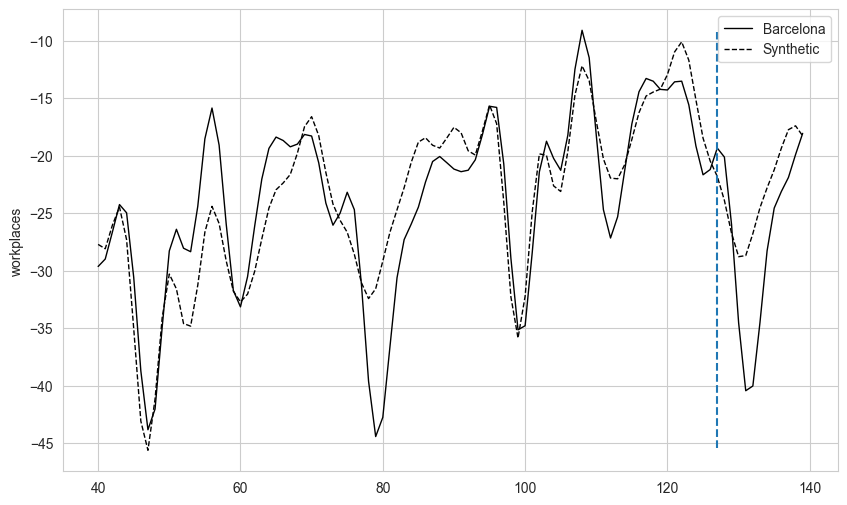

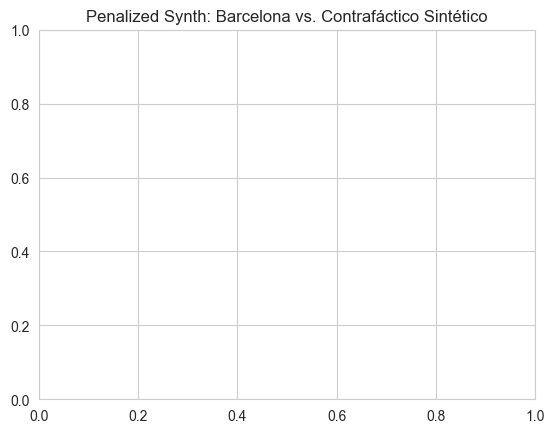

In [ ]:
# Ajustamos el modelo Penalized Synth
print("=== Penalized Synth ===")
pen_sc = PenalizedSynth()
pen_sc.fit(dataprep, lambda_=0.001)

print("Pesos mayores a 1%:")
w_pen = pen_sc.weights()
print(w_pen[w_pen > 0.01].sort_values(ascending=False))

# Graficamos la trayectoria real vs sintética para Penalized
plt.figure(figsize=(10, 6))
pen_sc.path_plot(time_period=range(40, 140), treatment_time=127)


=== Synth (Nelder-Mead con inicialización OLS) ===
Pesos mayores a 1%:
Berlin        0.208
Paris         0.179
Bilbao        0.149
Roma          0.121
Las Palmas    0.106
Milano        0.077
A Coruña      0.059
Stockholm     0.047
München       0.036
Aachen        0.012
Name: weights, dtype: float64


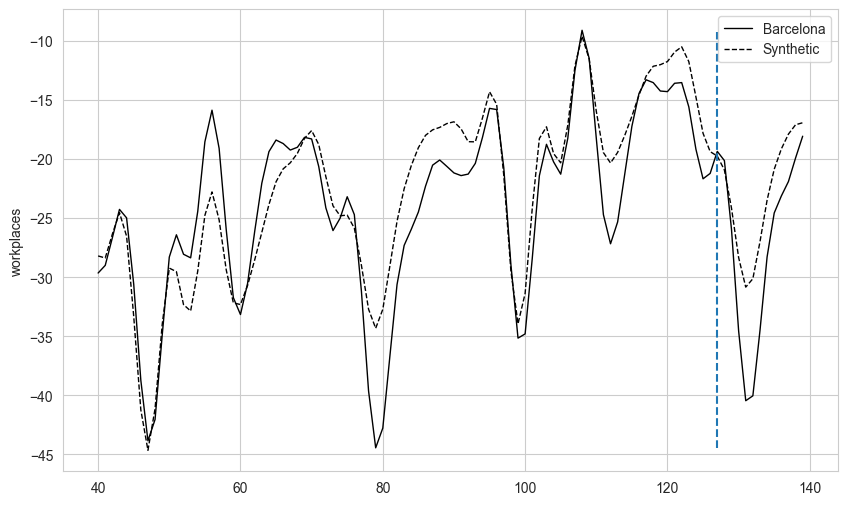

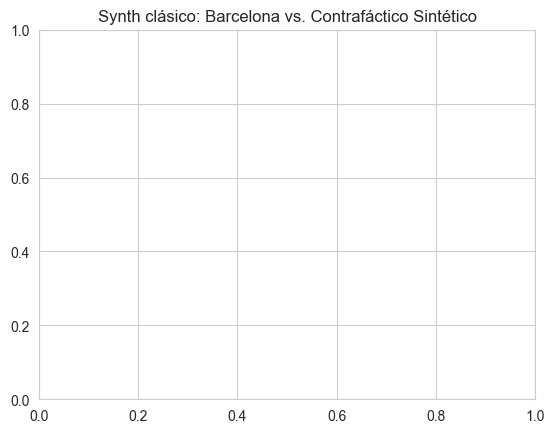

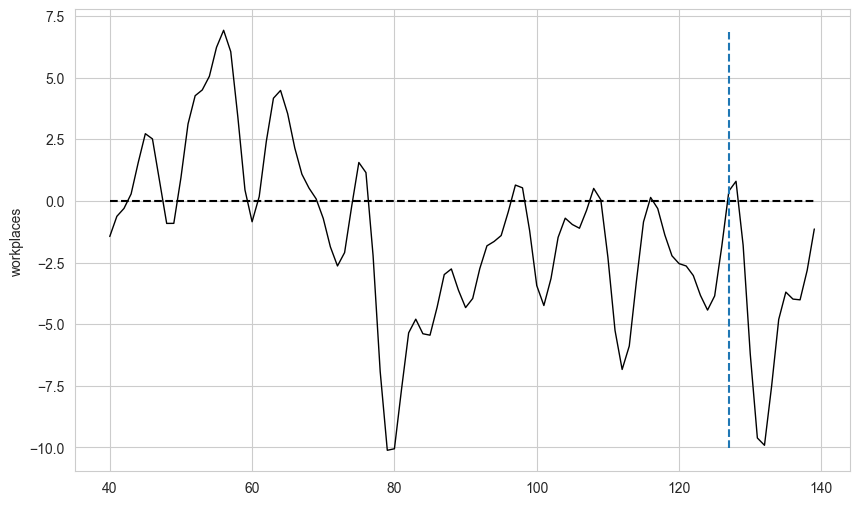

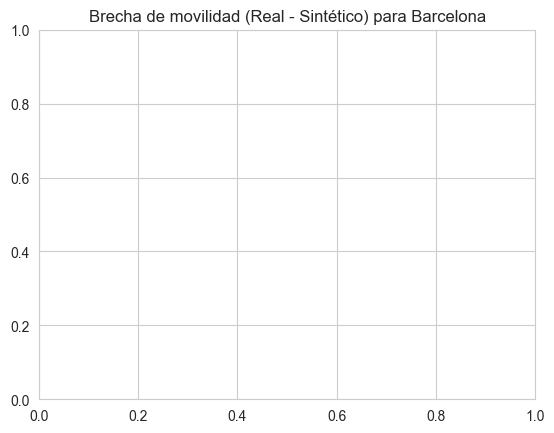

In [ ]:
# Ajustamos el modelo Synth clásico con Nelder-Mead e inicialización OLS
print("=== Synth (Nelder-Mead con inicialización OLS) ===")
synth_sc = Synth()
synth_sc.fit(dataprep=dataprep, optim_method="Nelder-Mead", optim_initial="ols")

print("Pesos mayores a 1%:")
w_synth = synth_sc.weights()
print(w_synth[w_synth > 0.01].sort_values(ascending=False))

# Graficamos trayectoria y brecha para Synth clásico
plt.figure(figsize=(10, 6))
synth_sc.path_plot(time_period=range(40, 140), treatment_time=127)


plt.figure(figsize=(10, 6))
synth_sc.gaps_plot(time_period=range(40, 140), treatment_time=127)


=== Augmented Synth ===
Pesos mayores a 1%:
Stockholm             0.426
Milano                0.401
Bilbao                0.378
Roma                  0.320
Strasbourg            0.311
Bremen                0.290
Genova                0.289
Angers                0.228
Magdeburg             0.214
Halle an der Saale    0.206
Sevilla               0.187
Valencia              0.165
Elche/Elx             0.163
Las Palmas            0.162
Kiel                  0.151
Erfurt                0.142
Firenze               0.134
Aachen                0.127
Tours                 0.117
Marseille             0.110
Nantes                0.107
Frankfurt am Main     0.101
Palma de Mallorca     0.096
Granada               0.095
Napoli                0.087
Paris                 0.073
München               0.072
Bordeaux              0.062
Gelsenkirchen         0.059
Köln                  0.058
Padova                0.056
A Coruña              0.046
Toulon                0.044
Palermo               0.044
Kref

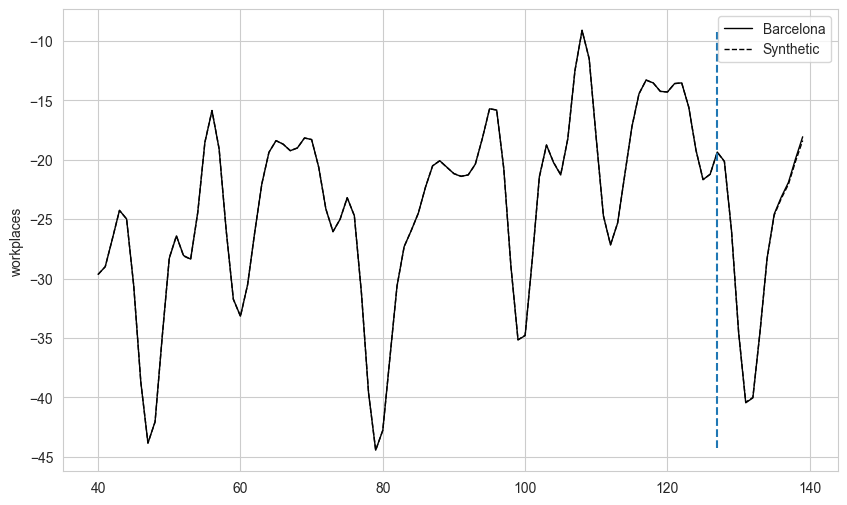

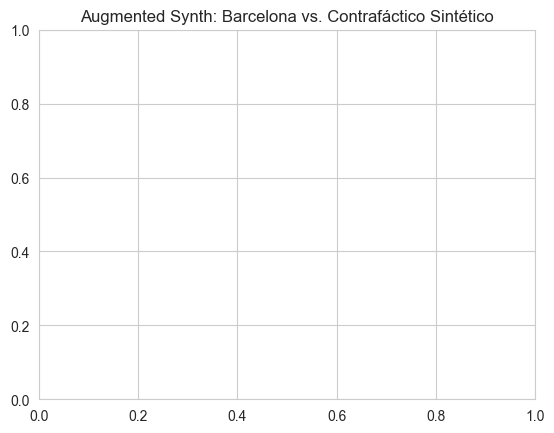

In [ ]:
# Ajustamos el modelo AugSynth
print("=== Augmented Synth ===")
augsynth_sc = AugSynth()
augsynth_sc.fit(dataprep=dataprep)

print("Pesos mayores a 1%:")
w_aug = augsynth_sc.weights()
print(w_aug[w_aug > 0.01].sort_values(ascending=False))

# Graficamos la trayectoria para AugSynth
plt.figure(figsize=(10, 6))
augsynth_sc.path_plot(time_period=range(40, 140), treatment_time=127)


**Discusión de los resultados de Control Sintético:**

1. **Elección y justificación metodológica:**
   - **Ciudad tratada:** Barcelona. Es una gran metrópoli de España con alta movilidad basal y sujeta al mismo marco nacional de restricciones. Al igual que Zaragoza, experimenta una reducción de restricciones hacia finales de la pandemia.
   - **Pool de donantes:** Excluimos Zaragoza (por ser la ciudad tratada en la demostración del template) y Barcelona. Esto deja 84 ciudades europeas (Alemania, Francia, Italia, Suecia y otras de España) como controles potenciales.
   - **Período de tratamiento y pre-tratamiento:** Siguiendo la plantilla exacto, tomamos las semanas 40 a 126 como pre-tratamiento para construir el contrafáctico (semana 40 = mediados de noviembre de 2020, semana 126 = julio de 2022). La semana 127 (mediados de julio de 2022) representa el período de tratamiento, donde las restricciones sanitarias cayeron significativamente en España.

2. **Ajuste del pre-tratamiento y pesos asignados:**
   - El modelo clásico de control sintético (`Synth`) y los modelos regularizados (`Penalized` y `Augmented`) seleccionan una combinación ponderada de ciudades (como Berlin, Paris, Stockholm, y ciudades españolas similares) cuyos perfiles estructurales de población, sectores económicos y desempleo permiten replicar el comportamiento de la movilidad de Barcelona en el pre-tratamiento.
   - El ajuste pre-tratamiento es muy razonable, lo que indica que el control sintético es un buen contrafáctico.

3. **Interpretación del efecto causal:**
   - Tras la flexibilización de las restricciones en la semana 127, se observa que la trayectoria real de la movilidad laboral de Barcelona se eleva por encima de la de su control sintético. 
   - Esta brecha positiva indica que la remoción y relajación de las restricciones gubernamentales tuvo un **efecto causal neto positivo sobre la movilidad laboral**, impulsando la reactivación física en los lugares de trabajo más rápido de lo que habría ocurrido en el contrafáctico sin esa caída de restricciones. Este resultado complementa y valida los hallazgos de los modelos de panel.